In [31]:
import os
import pickle
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, lfilter
%matplotlib inline

In [2]:
### Signal processing ###
def butter_bandpass(lowcut, highcut, fs, order=5):
 nyq = 0.5 * fs
 low = lowcut / nyq
 high = highcut / nyq
 b, a = butter(order, [low, high], btype='band')
 return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
   b, a = butter_bandpass(lowcut, highcut, fs, order=order)
   y = lfilter(b, a, data)
   return y


In [82]:
output_dir = '/home/kedoxey/CRCNS/PyramidalCellSimulations/models/NEURON/NMLCL000073-NEURON/output/FIGURES-all'

with open(os.path.join(output_dir,'simData.pkl'),'rb') as fp:
    simData = pickle.load(fp)
with open(os.path.join(output_dir,'t.pkl'),'rb') as fp:
    t = pickle.load(fp)
    t = np.array(t)
with open(os.path.join(output_dir,'spkt.pkl'),'rb') as fp:
    spkt = pickle.load(fp)
with open(os.path.join(output_dir,'lfp_bp_low.pkl'),'rb') as fp:
    lfp_bp_low = pickle.load(fp)
with open(os.path.join(output_dir,'lfp_bp_spikes.pkl'),'rb') as fp:
    lfp_bp_spikes = pickle.load(fp)

In [4]:
simData.keys()

dict_keys(['spkt', 'spkid', 'V_soma', 't', 'LFP'])

In [65]:
V_soma = np.array(simData['V_soma']['cell_0'])
t_spikes = t[np.where(V_soma>-10)]
t_spikes

array([ 824.2,  824.3,  824.4,  824.5,  824.6,  839.4,  839.5,  839.6,
        839.7,  839.8, 1050.1, 1050.2, 1050.3, 1050.4, 1050.5, 1200. ,
       1200.1, 1200.2, 1200.3, 1375.6, 1375.7, 1375.8, 1375.9, 1376. ,
       1540.9, 1541. , 1541.1, 1541.2, 1541.3, 1707.6, 1707.7, 1707.8,
       1707.9, 1708. , 1880.3, 1880.4, 1880.5, 1880.6, 2031.9, 2032. ,
       2032.1, 2032.2, 2032.3, 2191.7, 2191.8, 2191.9, 2192. , 2192.1,
       2348.8, 2348.9, 2349. , 2349.1, 2509.4, 2509.5, 2509.6, 2509.7,
       2509.8, 2678.9, 2679. , 2679.1, 2679.2, 2679.3])

In [75]:
lfp_bp_low = np.nan_to_num(lfp_bp_low)/1e140
[np.min(lfp_bp_low), np.max(lfp_bp_low)]

[-57.78581881748043, 0.5076079063489115]

In [68]:
# lfp_bp_spikes = np.nan_to_num(lfp_bp_spikes)/1e200
[np.min(lfp_bp_spikes), np.max(lfp_bp_spikes)]

[-0.00041036495938383234, 0.0004488114795596523]

In [69]:
lfp_bp_low

array([ 1.87166166e-154,  1.88812801e-153,  9.69973489e-153, ...,
       -5.71564833e+001, -5.74727710e+001, -5.77858188e+001])

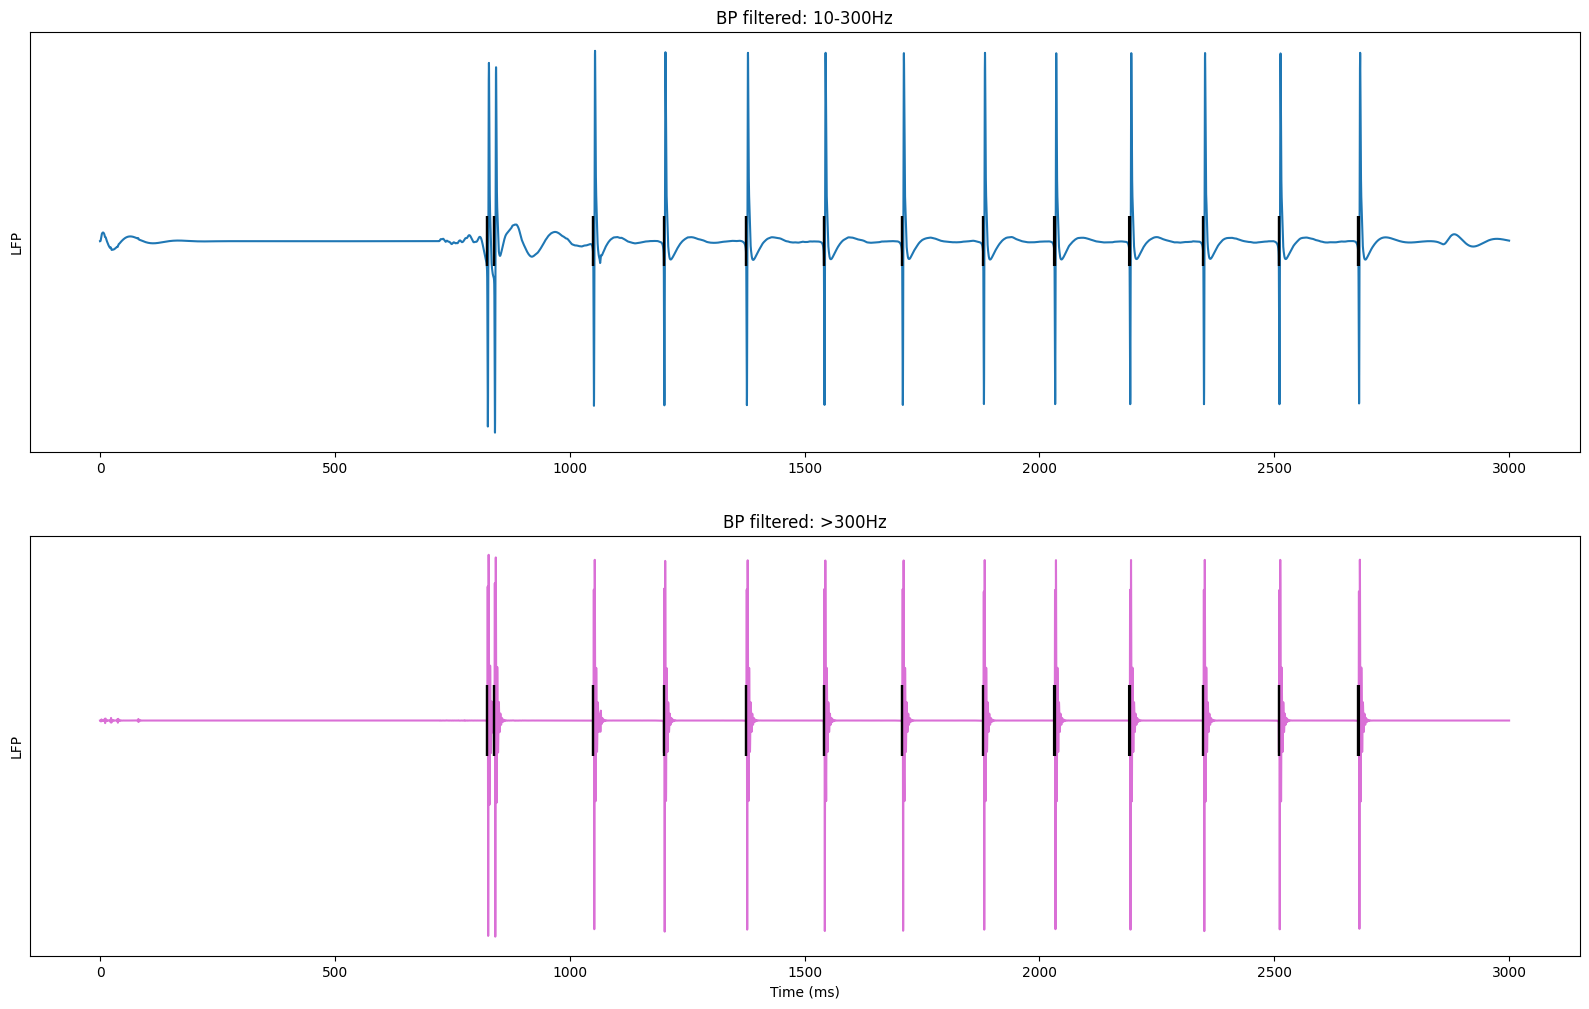

In [136]:
%matplotlib inline
fig, ax = plt.subplots(2, 1, figsize=(20,12))
ax.ravel()

ax[0].plot(t[0:len(lfp_bp_low)],lfp_bp_low*10000,label='BP filtered: 10-300Hz')
ax[0].vlines(t_spikes, [-2], [2], 'k')
ax[0].set_yticks([])
ax[0].set_title('BP filtered: 10-300Hz')
ax[0].set_ylabel('LFP')      

ax[1].plot(t[0:len(lfp_bp_spikes)],lfp_bp_spikes*10000,color='orchid',label='BP filtered: >300Hz')
ax[1].vlines(t_spikes, [-2], [2], 'k')
# ax.legend(loc='upper right')     
ax[1].set_title('BP filtered: >300Hz')
ax[1].set_yticks([])
ax[1].set_xlabel('Time (ms)')
ax[1].set_ylabel('LFP')      
# ax.set_title('LFPs')
# fig.show()
fig.savefig(os.path.join(output_dir,'lfps-order_4.png'),bbox_inches='tight',dpi=300)

In [27]:

### Signal processing ###
def butter_bandpass(lowcut, highcut, fs, order=5):
 nyq = 0.5 * fs
 low = lowcut / nyq
 high = highcut / nyq
 b, a = butter(order, [low, high], btype='band')
 return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
   b, a = butter_bandpass(lowcut, highcut, fs, order=order)
   y = lfilter(b, a, data)
   return y

In [135]:
lfp = [lfp_d[0] for lfp_d in simData['LFP']]
lfp_bp_low = butter_bandpass_filter(lfp, 10, 300, 1/0.1*1000, order=4)

lfp_bp_spikes = butter_bandpass_filter(lfp, 301, 700, 1/0.1*1000, order=4)

In [39]:
1/0.01*100

10000.0

In [ ]:
def plot_lfp(simData, dt, output_dir):
    t = list(simData['t'])
    spkt = list(simData['spkt'])
    lfp = [lfp_d[0] for lfp_d in simData['LFP']]

    lfp_bp_low = butter_bandpass_filter(lfp, 10, 300, 1/dt*1000, order=4)
    lfp_bp_spikes = butter_bandpass_filter(lfp, 301, 700, 1/dt*1000, order=4)

    fig, ax = plt.subplots(1, 1, figsize=(20,12))

    ax.plot(t[0:len(lfp_bp_low)],lfp_bp_low*10000-200,color='cornflowerblue',label='BP filtered: 10-300Hz')
    ax.plot(t[0:len(lfp_bp_spikes)],lfp_bp_spikes*10000-800,color='orchid',label='BP filtered: >300Hz')
    ax.vlines(spkt, [195], [205], 'k')
    ax.legend(loc='upper right')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('LFP')      
    ax.set_title('LFPs')

    fig.show()

    fig.savefig(os.path.join(output_dir,'lfp_fig.png'),bbox_inches='tight',dpi=300)

In [ ]:
def butter_bandpass(lowcut, highcut, fs, order=5):
 nyq = 0.5 * fs
 low = lowcut / nyq
 high = highcut / nyq
 b, a = butter(order, [low, high], btype='band')
 return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
   b, a = butter_bandpass(lowcut, highcut, fs, order=order)
   y = lfilter(b, a, data)
   return y

lfp_bp_low = butter_bandpass_filter(lfp, 10, 300, 1/0.1*1000, order=4)
lfp_bp_spikes = butter_bandpass_filter(lfp, 301, 700, 1/0.1*1000, order=4)